<a href="https://colab.research.google.com/github/Spicyredd/Learn_PyTorch/blob/master/03_pytorch_computer_vision_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. PyTorch Computer Vision Exercises

The following is a collection of exercises based on computer vision fundamentals in PyTorch.

They're a bunch of fun.

You're going to get to write plenty of code!

## Resources

1. These exercises are based on [notebook 03 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/03_pytorch_computer_vision/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/_PibmqpEyhA).
  * **Note:** Going through these exercises took me just over 3 hours of solid coding, so you should expect around the same.
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [ ]:
# Check for GPU
!nvidia-smi

Thu May 29 05:13:53 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             31W /   70W |     166MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# Import torch
import torch

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# TODO: Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

2.6.0+cu124
Using device: cuda


## 1. What are 3 areas in industry where computer vision is currently being used?

1. Virtual Mirrors in retail industry
2. Self-checkout stores
3. Driverless Trucks

## 2. Search "what is overfitting in machine learning" and write down a sentence about what you find.

1. Overfitting in machine learning is when the model captures the training data perfectly but fails to generalize which causes model to have a bad loss/accuracy during model validation

## 3. Search "ways to prevent overfitting in machine learning", write down 3 of the things you find and a sentence about each.
> **Note:** there are lots of these, so don't worry too much about all of them, just pick 3 and start with those.

1. Regularization
2. Don't go overboard with epochs
3. Split data in to training and testing sets

## 4. Spend 20-minutes reading and clicking through the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/).

* Upload your own example image using the "upload" button on the website and see what happens in each layer of a CNN as your image passes through it.

## 5. Load the [`torchvision.datasets.MNIST()`](https://pytorch.org/vision/stable/generated/torchvision.datasets.MNIST.html#torchvision.datasets.MNIST) train and test datasets.

In [ ]:
from torchvision.datasets import MNIST
import torchvision

# Download the data if not exist
train_data = MNIST(
    root="dataset",
    train=True,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)

test_data = MNIST(
    root="dataset",
    train=False,
    download=True,
    transform=torchvision.transforms.ToTensor(),
    target_transform=None
)


## 6. Visualize at least 5 different samples of the MNIST training dataset.

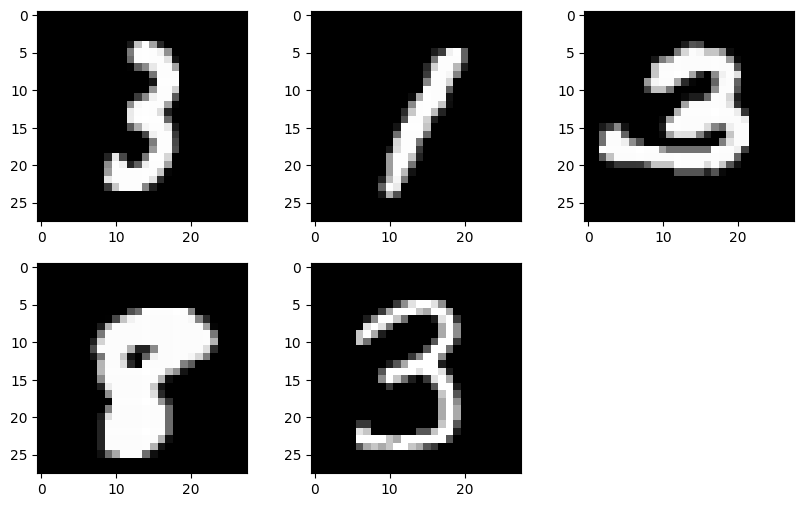

In [ ]:
import matplotlib.pyplot as plt
import random
random_samples = [train_data[random.randint(0, len(train_data))] for i in range(5)]
plt.figure(figsize=(10, 6))
nrows = 2
ncols = 3
for idx, image in enumerate(random_samples, start=1):
  plt.subplot(nrows, ncols, idx)
  plt.imshow(image[0].squeeze(), cmap="gray")

## 7. Turn the MNIST train and test datasets into dataloaders using `torch.utils.data.DataLoader`, set the `batch_size=32`.

In [ ]:
from torch.utils.data import DataLoader
# Setup the batch size hyperparameter

BATCH_SIZE=32

train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

## 8. Recreate `model_2` used in notebook 03 (the same model from the [CNN Explainer website](https://poloclub.github.io/cnn-explainer/), also known as TinyVGG) capable of fitting on the MNIST dataset.

In [ ]:
import torch
from torch import nn

class MNISTModelV0(nn.Module):
  def __init__(self, in_channels, hidden_units, output_shape):
    super().__init__()
    self.conv_layer_1 = nn.Sequential(
        nn.Conv2d(in_channels=in_channels,
                  out_channels=hidden_units,
                  kernel_size=2,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=3,
                  stride=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )
    self.conv_layer_2 = nn.Sequential(
        nn.Conv2d(in_channels=hidden_units,
                  out_channels=hidden_units,
                  kernel_size=2,
                  stride=1),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=2,
            stride=1,
            padding=1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=3),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=hidden_units * 16,
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_layer_1(x)
    x = self.conv_layer_2(x)
    x = self.classifier(x)
    return x

In [ ]:
class_names = train_data.classes
class_names

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

In [ ]:
class_to_idx = train_data.class_to_idx
class_to_idx

{'0 - zero': 0,
 '1 - one': 1,
 '2 - two': 2,
 '3 - three': 3,
 '4 - four': 4,
 '5 - five': 5,
 '6 - six': 6,
 '7 - seven': 7,
 '8 - eight': 8,
 '9 - nine': 9}

In [ ]:
model_2 = MNISTModelV0(in_channels=1,
                       hidden_units=10,
                       output_shape=len(class_names)).to(device)

## 9. Train the model you built in exercise 8. for 5 epochs on CPU and GPU and see how long it takes on each.

In [ ]:
!pip install -q torchmetrics

In [ ]:
from torchmetrics import Accuracy
accuracy_fn = Accuracy(task="MULTICLASS", num_classes=len(class_names)).to(device)

In [ ]:
from tqdm.auto import tqdm

# Setup loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(params=model_2.parameters(),
                            lr=0.1)

# Setup epochs
epochs = 5

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n-----")
  loss, accuracy = 0, 0
  for X, y in tqdm(train_loader):
    X, y = X.to(device), y.to(device)
    y_logit = model_2(X).squeeze()
    y_preds = y_logit.argmax(dim=1)

    in_loss = loss_fn(y_logit, y)
    loss += in_loss
    accuracy += accuracy_fn(preds=y_preds,
                            target=y)

    optimizer.zero_grad()

    in_loss.backward()

    optimizer.step()

  loss /= len(train_loader)
  accuracy /= len(train_loader)
  print(f"Train Loss: {loss:.5f} | Train Accuracy: {accuracy:.2f}%")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0
-----


  0%|          | 0/1875 [00:00<?, ?it/s]

KeyboardInterrupt: 

## 10. Make predictions using your trained model and visualize at least 5 of them comparing the prediciton to the target label.

In [ ]:
import matplotlib.pyplot as plt

random_samples = [test_data[random.randint(1, len(test_loader))] for x in range(5)]
plt.figure(figsize=(10,6))
nrows = 2
ncols = 3
model_2.eval()
with torch.inference_mode():
  for idx, (image, label) in enumerate(random_samples, start=1):
    y_pred = model_2(image.unsqueeze(dim=1).to(device)).argmax(dim=1)
    plt.subplot(nrows, ncols, idx)
    if y_pred == label:
      plt.title(f"True: {label} | Predicted: {y_pred[0]}", c="g")
      plt.imshow(image.squeeze())
    else:
      plt.title(f"True: {label} | Predicted: {y_pred[0]}", c="r")
      plt.imshow(image.squeeze())
  plt.tight_layout()

## 11. Plot a confusion matrix comparing your model's predictions to the truth labels.

In [ ]:
from tqdm.auto import tqdm
y_preds = []
model_2.eval()

with torch.inference_mode():
  for X, y in tqdm(test_data, desc="Making predictions..."):
      X, y = X.to(device), y
      y_logit = model_2(X.unsqueeze(dim=1))

      y_pred = y_logit.argmax(dim=1)

      y_preds.append(y_pred.cpu())

y_pred_tensor = torch.cat(y_preds)
y_pred_tensor[:10]

In [ ]:
# See if required packages are installed and if not, install them...
try:
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")
  assert int(mlxtend.__version__.split(".")[1] >= 19, "mlxtend version should be 0.19. or higher")
except Exception as e:
  !pip install -q torchmetrics -U mlxtend
  import torchmetrics, mlxtend
  print(f"mlxtend version: {mlxtend.__version__}")

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

# 2. Setup confusion instance and compare predictions to targets
confmat = ConfusionMatrix(task="multiclass", num_classes=len(class_names))
confmat_tensor = confmat(preds=y_pred_tensor,
                         target=test_data.targets)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10,7)
)

## 12. Create a random tensor of shape `[1, 3, 64, 64]` and pass it through a `nn.Conv2d()` layer with various hyperparameter settings (these can be any settings you choose), what do you notice if the `kernel_size` parameter goes up and down?

In [ ]:
random_tensor = torch.randn([1, 3, 64, 64])

model = nn.Conv2d(
    in_channels=3,
    out_channels=1,
    kernel_size=5,
    stride=4,
    padding=1
)

out = model(random_tensor)
print(out.shape)

## 13. Use a model similar to the trained `model_2` from notebook 03 to make predictions on the test [`torchvision.datasets.FashionMNIST`](https://pytorch.org/vision/main/generated/torchvision.datasets.FashionMNIST.html) dataset.
* Then plot some predictions where the model was wrong alongside what the label of the image should've been.
* After visualing these predictions do you think it's more of a modelling error or a data error?
* As in, could the model do better or are the labels of the data too close to each other (e.g. a "Shirt" label is too close to "T-shirt/top")?

In [ ]:
class FashionMNISTModelV2(nn.Module):
  def __init__(self, in_channels, hidden_units, output_shape):
    super().__init__()
    self.conv_layer_1=nn.Sequential(
        nn.Conv2d(
        in_channels=in_channels,
        out_channels=hidden_units,
        kernel_size=3,
        stride=2
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=2,
            stride=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2)
    )

    self.conv_layer_2=nn.Sequential(
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=1,
            stride=1
        ),
        nn.ReLU(),
        nn.Conv2d(
            in_channels=hidden_units,
            out_channels=hidden_units,
            kernel_size=2,
            stride=1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=1)
    )

    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features=int(hidden_units*25),
                  out_features=output_shape)
    )

  def forward(self, x):
    x = self.conv_layer_1(x)
    x = self.conv_layer_2(x)
    x = self.classifier(x)
    return x

In [ ]:
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader

fashion_train = FashionMNIST(
    root="fashion",
    train=True,
    transform=torchvision.transforms.ToTensor(),
    download=True
)

fashion_test = FashionMNIST(
    root="fashion",
    train=False,
    transform=torchvision.transforms.ToTensor(),
    download=True
)

train_loader = DataLoader(
    dataset=fashion_train,
    batch_size=32,
    shuffle=True
)

test_loader = DataLoader(
    dataset=fashion_test,
    batch_size=32,
    shuffle=False
)


model_3 = FashionMNISTModelV2(
    in_channels=1,
    hidden_units=10,
    output_shape=10
).to(device)
model_3

optimizer = torch.optim.SGD(params=model_3.parameters(),
                           lr=0.1)
loss_fn = nn.CrossEntropyLoss()

class_names = fashion_train.classes

In [ ]:
def train_model(
    dataloader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    optimizer: torch.optim.Optimizer,
    device,
    accuracy_fn
):
    model.train()
    loss, accuracy = 0, 0
    for batch, (X, y) in tqdm(enumerate(dataloader)):
      X,y = X.to(device), y.to(device)
      y_logit = model(X).squeeze()
      y_pred = y_logit.argmax(dim=1)
      in_loss = loss_fn(y_logit, y)
      loss += in_loss
      accuracy += accuracy_fn(preds=y_pred, target=y)

      optimizer.zero_grad()

      in_loss.backward()

      optimizer.step()

    loss /= len(dataloader)
    accuracy /= len(dataloader)
    print(f"Train loss: {loss:.3f} | Train accuracy: {accuracy:.2f}%")

In [ ]:
from tqdm.auto import tqdm
epochs = 3
for epoch in tqdm(range(epochs)):
  print(f"Epochs: {epoch}")
  train_model(train_loader, model_3, loss_fn, optimizer, device, accuracy_fn)

  0%|          | 0/3 [00:00<?, ?it/s]

Epochs: 0


0it [00:00, ?it/s]

Train loss: 0.787 | Train accuracy: 0.71%
Epochs: 1


0it [00:00, ?it/s]

Train loss: 0.463 | Train accuracy: 0.83%
Epochs: 2


0it [00:00, ?it/s]

Train loss: 0.419 | Train accuracy: 0.85%


In [ ]:
def test_model(
    dataloader: torch.utils.data.DataLoader,
    model: torch.nn.Module,
    loss_fn: torch.nn.Module,
    device,
    accuracy_fn
):
  model.eval()
  with torch.inference_mode():
    loss, accuracy = 0, 0
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      y_logit = model(X).squeeze()
      y_pred = y_logit.argmax(dim=1)
      in_loss = loss_fn(y_logit, y)
      loss += in_loss
      accuracy += accuracy_fn(preds=y_pred,
                              target=y)
    loss /= len(dataloader)
    accuracy /= len(dataloader)
    print(f"Test loss: {loss:.3f} | Test accuracy: {accuracy:.2f}%")

In [ ]:
test_model(test_loader,
           model_3,
           loss_fn,
           device,
           accuracy_fn)

Test loss: 0.431 | Test accuracy: 0.85%


In [ ]:
y_preds = []

model_3.eval()
with torch.inference_mode():
  for X,y in tqdm(test_loader):
    X, y = X.to(device), y.to(device)
    y_pred = model_3(X).squeeze().argmax(dim=1)
    y_preds.append(y_pred.to("cpu"))
  y_pred_tensor = torch.cat(y_preds)


  0%|          | 0/313 [00:00<?, ?it/s]

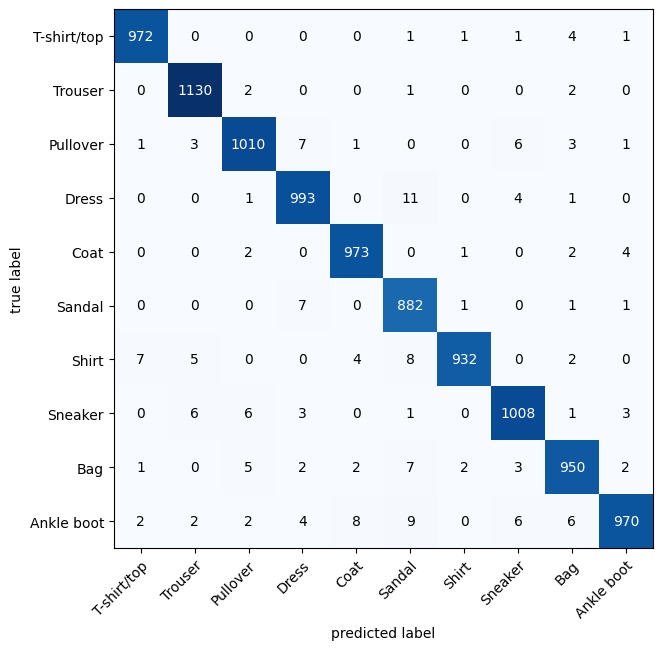

In [ ]:
from torchmetrics import ConfusionMatrix
from mlxtend.plotting import plot_confusion_matrix

confmat_FashionMNIST = ConfusionMatrix(
    task="multiclass",
    num_classes=len(class_names)
)

confmat_tensor_Fashion = confmat_FashionMNIST(
    preds = y_pred_tensor,
    target = test_data.targets
)

fig, ax = plot_confusion_matrix(
    conf_mat=confmat_tensor.numpy(),
    class_names=class_names,
    figsize=(10,7)
)